In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import talib as ta
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import datetime as dt

In [2]:
# Dow30 tickers
tickers = {
    "AAPL", "AMGN", "AXP", "BA", "CAT", "CRM", "CSCO", "CVX", "DIS", "DOW",
    "GS", "HD", "HON", "IBM", "INTC", "JNJ", "JPM", "KO", "MCD", "MMM",
    "MRK", "MSFT", "NKE", "PG", "SHW", "TRV", "UNH", "V", "VZ", "WMT"
}

# Download daily data for all tickers

start_date = '2025-01-01'
end_date = '2026-01-07'

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    group_by='ticker',
    auto_adjust=True, 
    threads=True
)

[*********************100%***********************]  30 of 30 completed


In [3]:
data.head()

Ticker            AMGN                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2025-01-02  253.914973  255.270834  250.166977  251.106400  2357400   
2025-01-03  251.803733  253.818150  251.600362  252.985275  2979700   
2025-01-06  250.883662  252.956215  248.946710  250.438171  4668200   
2025-01-07  252.016745  256.849429  251.174176  253.798737  3173700   
2025-01-08  253.711605  255.919729  251.629388  255.880981  2421500   

Ticker           INTC                                             ...  \
Price            Open       High        Low      Close    Volume  ...   
Date                                                              ...   
2025-01-02  20.230000  20.430000  20.000000  20.219999  46438500  ...   
2025-01-03  20.389999  20.670000  20.059999  20.559999  48983900  ...   
2025-01-06  20.830000  20.980000  19.780001  19.870001  83271000  ...   
2025-01-07  20.020000  20.340000  19.900000  20.010000  61726100  ...   
2025-01-08  19.830000  20.120001  19.709999  19.879999  47897100  ...   

Ticker              PG                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2025-01-02  163.763346  164.367397  161.639466  161.707657  5401700   
2025-01-03  161.970713  162.214278  160.022194  160.879547  5256600   
2025-01-06  158.619247  159.291488  156.310256  156.466141  8731700   
2025-01-07  157.304017  158.424410  156.602549  157.148132  8447400   
2025-01-08  156.846122  158.219817  156.436935  157.927551  4974800   

Ticker            MRK                                             
Price            Open       High        Low      Close    Volume  
Date                                                              
2025-01-02  96.646641  96.714105  95.249181  95.576859   6153300  
2025-01-03  95.740709  96.135857  95.114266  95.547958   6070300  
2025-01-06  95.191350  96.694833  94.854032  96.106934  10111100  
2025-01-07  96.502080  99.239185  96.424984  97.359833  10890900  
2025-01-08  97.051432  97.118896  94.497453  96.232231   8654700  

[5 rows x 150 columns]

In [4]:
def ma50_score(df):
    """
    Enhanced MA50 score:
    Combines % distance from MA50, short-term slope, and long-term trend filter.
    Score is normalized between -1 and +1.
    """
    ma50_series = ta.SMA(df['Close'], timeperiod=50)
    ma200_series = ta.SMA(df['Close'], timeperiod=200)

    ma50 = ma50_series.iloc[-1]
    ma50_5ago = ma50_series.iloc[-5]
    ma200 = ma200_series.iloc[-1]
    close = df['Close'].iloc[-1]

    # Distance from MA50 (capped)
    dist = (close - ma50) / ma50
    dist_score = max(-1, min(1, dist))

    # Slope of MA50 over last 5 periods
    slope = (ma50 - ma50_5ago) / ma50
    slope_score = max(-1, min(1, slope * 5))  # Scale it for range

    # Long-term regime
    regime = 1 if ma50 > ma200 else -1

    # Final score: combine all (tune weights as needed)
    score = 0.5 * dist_score + 0.3 * slope_score + 0.2 * regime
    return max(-1, min(1, score))

In [5]:
def rsi_score_momentum(df, rsi_period=14, lookback=20):
    """
    Enhanced RSI momentum score:
    Measures recent RSI change normalized by 2x rolling std of RSI changes. 
    Positive = RSI rising strongly, Negative = RSI falling strongly.
    Returns value between -1 and +1.
    """
    rsi_series = ta.RSI(df['Close'], timeperiod=rsi_period)
    rsi_change = rsi_series.diff()

    # Current change
    change = rsi_change.iloc[-1]
    # Rolling standard deviation of RSI changes
    stdev = rsi_change.rolling(lookback).std().iloc[-1]
    if pd.isna(stdev) or stdev == 0:
        return 0.0 # no meaningful movement

    score = change / (2 * stdev)
    return max(-1, min(1, score))

In [6]:
def vol_score(df, lookback_vol=20, lookback_trend=5):
    """
    Enhanced volume score:
    - Combines current volume ratio (capped) alignned with trend sign (50%)
    - With a short-term price slope normalized as trend strength (50%).
    """
    # --- Volume component ---
    avg_vol = df['Volume'].rolling(window=lookback_vol).mean().iloc[-1]
    curr_vol = df['Volume'].iloc[-1]
    ratio = curr_vol / avg_vol if avg_vol != 0 else 0
    ratio = min(ratio, 1.0)

    if df['Close'].iloc[-1] > df['Close'].iloc[-2]:
        trend_sign = 1
    elif df['Close'].iloc[-1] < df['Close'].iloc[-2]:
        trend_sign = -1
    else:
        trend_sign = 0
    score_volume = ratio * trend_sign
    return max(-1, min(1, score_volume))

In [7]:
results = []

for ticker in tickers:

    df_ticker = data[ticker][['Close', 'Volume']].dropna()
    result = {
        'Ticker': ticker,
        'ma50_score': ma50_score(df_ticker),
        'rsi_score': rsi_score_momentum(df_ticker),
        'vol_score': vol_score(df_ticker),
        # 'bb_score': bb_score_binary(df_ticker)
    }
    # Combine scores into a final score
    result['final_score'] = (result['ma50_score'] + result['rsi_score'] + result['vol_score'] ) / 3
    results.append(result)


scanner_df = pd.DataFrame(results)
scanner_df.head()

,Ticker,ma50_score,rsi_score,vol_score,final_score
0,CVX,0.218720,-1.000000,-1.000000,-0.593760
1,INTC,0.228972,0.361410,0.989935,0.526772
2,HD,-0.223653,0.892147,1.000000,0.556164
3,MSFT,0.174904,0.815376,1.000000,0.663427
4,CRM,-0.172611,0.724525,0.879969,0.477294


In [8]:
scanner_df

,Ticker,ma50_score,rsi_score,vol_score,final_score
0,CVX,0.218720,-1.000000,-1.000000,-0.593760
1,INTC,0.228972,0.361410,0.989935,0.526772
2,HD,-0.223653,0.892147,1.000000,0.556164
3,MSFT,0.174904,0.815376,1.000000,0.663427
4,CRM,-0.172611,0.724525,0.879969,0.477294
5,KO,0.182399,-0.064216,-1.000000,-0.293939
6,AXP,0.231376,0.341001,1.000000,0.524126
7,JNJ,0.220191,0.116157,1.000000,0.445449
8,HON,-0.174948,0.670909,1.000000,0.498654
9,DIS,-0.174283,0.161417,0.696342,0.227825


<Figure size 1200x500 with 0 Axes>

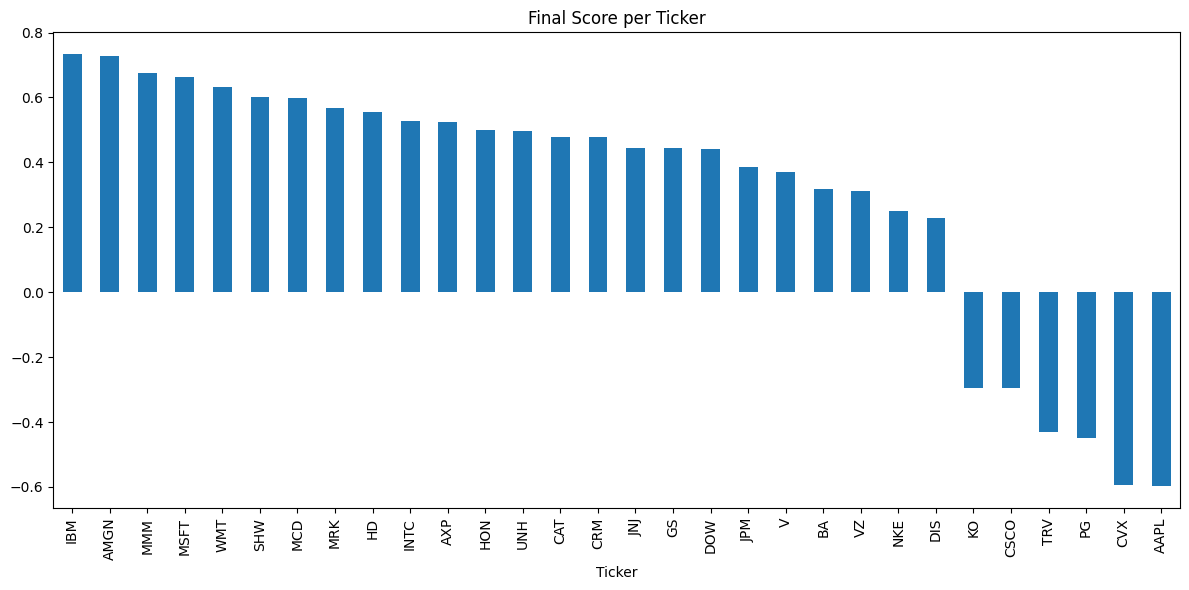

In [9]:
plt.figure(figsize=(12,5))
scanner_df.sort_values('final_score', ascending=False).plot(
    x='Ticker', y='final_score', kind='bar', legend=False, figsize=(12,6), title='Final Score per Ticker')
plt.tight_layout()
plt.show()

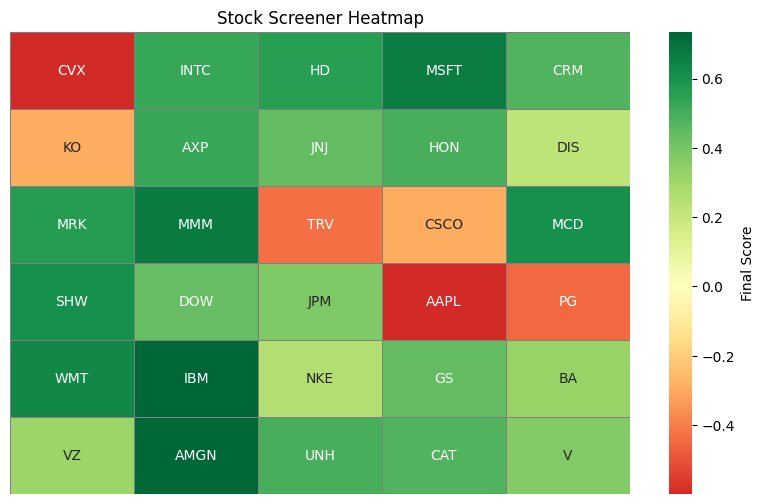

In [10]:
# Ensure scanner_df is sorted for stable layout
scores = scanner_df.copy().reset_index(drop=True)
values = scores['final_score'].values

# Determine grid size (approx square)
n = len(values)
rows = int(np.ceil(np.sqrt(n)))
cols = int(np.ceil(n / rows))

grid = np.full((rows, cols), np.nan)
labels = np.full((rows, cols),  "", dtype=object)

for i, val in enumerate(values):
    r = i // cols
    c = i % cols
    grid[r, c] = val
    labels[r, c] = scores['Ticker'].iloc[i]

plt.figure(figsize=(10, 6))
ax = sns.heatmap(grid, annot=labels, fmt='', cmap='RdYlGn', center=0, cbar_kws={'label': 'Final Score'}, linewidths=0.5, linecolor='gray')
plt.title('Stock Screener Heatmap')
plt.yticks([])
plt.xticks([])
plt.show()

In [11]:
data['AAPL'].tail()

Price,Open,High,Low,Close,Volume
Date,,,,,
2025-12-30,272.809998,274.079987,272.279999,273.079987,22139600
2025-12-31,273.059998,273.679993,271.750000,271.859985,27293600
2026-01-02,272.260010,277.839996,269.000000,271.010010,37838100
2026-01-05,270.640015,271.510010,266.140015,267.260010,45647200
2026-01-06,267.000000,267.549988,262.119995,262.359985,52352100


<Figure size 1200x600 with 0 Axes>

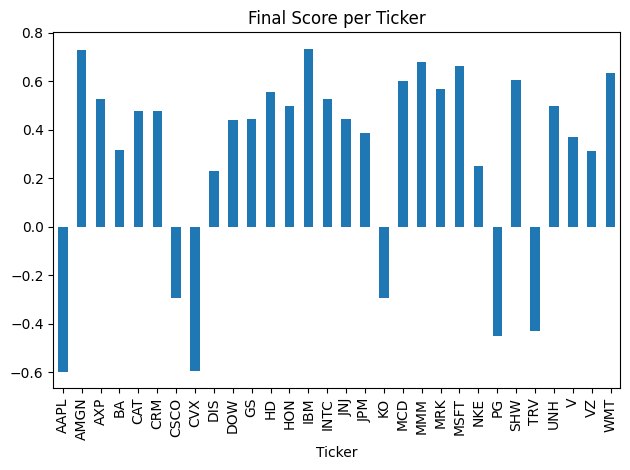

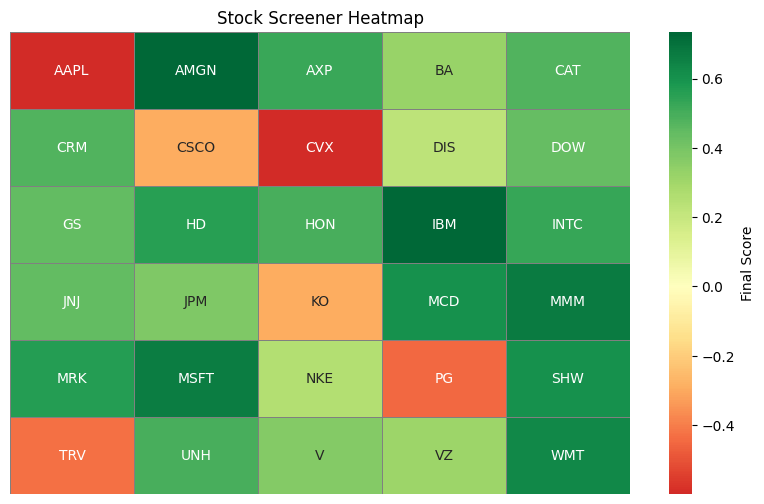

,Ticker,ma50_score,rsi_score,vol_score,final_score
0,AAPL,0.183857,-0.979615,-1.000000,-0.598586
1,AMGN,0.220723,1.000000,0.963415,0.728046
2,AXP,0.231376,0.341001,1.000000,0.524126
3,BA,-0.129838,0.170474,0.912738,0.317791
4,CAT,0.258743,0.175778,1.000000,0.478174
5,CRM,-0.172611,0.724525,0.879969,0.477294
6,CSCO,0.206765,-0.248597,-0.842478,-0.294770
7,CVX,0.218720,-1.000000,-1.000000,-0.593760
8,DIS,-0.174283,0.161417,0.696342,0.227825
9,DOW,-0.135984,0.457961,1.000000,0.440659


In [12]:
# Sort tickers alphabetically
tickers_sorted = sorted(tickers)

# Recreate scanner_df with sorted tickers
results_sorted = []

for ticker in tickers_sorted:
    df_ticker = data[ticker][['Close', 'Volume']].dropna()
    result = {
        'Ticker': ticker,
        'ma50_score': ma50_score(df_ticker),
        'rsi_score': rsi_score_momentum(df_ticker),
        'vol_score': vol_score(df_ticker),
    }
    result['final_score'] = (result['ma50_score'] + result['rsi_score'] + result['vol_score']) / 3
    results_sorted.append(result)

scanner_df = pd.DataFrame(results_sorted)

# Recreate the bar plot with sorted data
plt.figure(figsize=(12, 6))
scanner_df.plot(x='Ticker', y='final_score', kind='bar', legend=False, title='Final Score per Ticker')
plt.tight_layout()
plt.show()

# Recreate the heatmap with sorted data
scores = scanner_df.copy().reset_index(drop=True)
values = scores['final_score'].values

n = len(values)
rows = int(np.ceil(np.sqrt(n)))
cols = int(np.ceil(n / rows))

grid = np.full((rows, cols), np.nan)
labels = np.full((rows, cols), "", dtype=object)

for i, val in enumerate(values):
    r = i // cols
    c = i % cols
    grid[r, c] = val
    labels[r, c] = scores['Ticker'].iloc[i]

plt.figure(figsize=(10, 6))
sns.heatmap(grid, annot=labels, fmt='', cmap='RdYlGn', center=0, cbar_kws={'label': 'Final Score'}, linewidths=0.5, linecolor='gray')
plt.title('Stock Screener Heatmap')
plt.yticks([])
plt.xticks([])
plt.show()

scanner_df